# MethaneSET · Landsat 8/9
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IPL-UV/taco-methaneset/blob/main/methaneset-codes/notebooks/02_l89.ipynb)

**Landsat 8/9 subsets for methane plume detection: pretraining (plume-free) and finetune (with plumes).**

What you will do here:
1. Open the collections (no raster touched yet) and read their schema.
2. Explore the catalog: splits, countries, years, emission rates, solar geometry.
3. Look inside one sample (target, the four backgrounds, the `ch4` retrieval, the plume mask, the DEM).
4. Reproduce the **MBMP** enhancement from the SWIR bands and compare with the distributed `ch4`.
5. Train a **minimal pixel classifier** as an honest baseline (respecting the split).

Data: `methaneset-l89-pretraining` (21,919 plume-free samples) and `methaneset-l89-finetune` (1,353 with plumes), CC-BY-NC-SA-4.0.
See also: `01_s2`, `03_emit`, `04_bank`.

## 1. Setup
No credentials needed. `common.py` resolves the data: local folder if present
(`METHANESET_DATA`), otherwise the Hugging Face copy.

In [1]:
import os, urllib.request
if not os.path.exists("common.py"):          # on Colab the notebook travels alone
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/IPL-UV/taco-methaneset/main/methaneset-codes/notebooks/common.py",
        "common.py")
try:
    import tacoreader, rasterio, sklearn
except ImportError:
    %pip install "tacoreader>=2.4,<3" rasterio scikit-learn matplotlib pandas pyarrow
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import common as C
C.style()
import tacoreader; print("tacoreader", tacoreader.__version__)

tacoreader 2.4.21


## 2. Load the collections
A MethaneSET dataset is a *TACO*: one Parquet catalog (`level0`: one row per sample,
queryable with SQL) plus one folder per sample with the raster layers. Loading is lazy:
nothing is downloaded until you read a sample.

In [2]:
pre = C.load("methaneset-l89-pretraining")
ft = C.load("methaneset-l89-finetune")
pre_df = pre.data.to_pandas()      # the catalog as a plain pandas DataFrame
ft_df = ft.data.to_pandas()
print("pretraining:", pre_df.shape[0], "samples")
print("finetune   :", ft_df.shape[0], "samples")

[common] methaneset-l89-pretraining: local


[common] methaneset-l89-finetune: local


pretraining: 21919 samples
finetune   : 1353 samples


`level0` columns are namespaced: `detection:` (annotations and emission rates),
`target:` (acquisition geometry), `bg:` (background references), `site:`, `quality:`,
`meteo:` (ERA5-Land wind), `geoenrich:` (population, elevation...), `split`.
In the pretraining subset `detection:ch4_fluxrate` is NULL by construction: there is no plume.
A minority of Landsat granules (Real-Time products) carry placeholder angles near 0°, so we filter
`target:sza > 1` before showing acquisition geometry.

In [3]:
print(sorted([c for c in ft_df.columns if c.startswith(("detection:", "target:"))]))
ft_df.query("`target:sza` > 1")[["target:tile", "target:sensor", "target:sza", "target:vza",
         "target:saa", "target:raa", "detection:ch4_fluxrate", "site:country", "split"]].head(3)

['detection:case_study', 'detection:ch4_fluxrate', 'detection:ch4_fluxrate_std', 'detection:offshore', 'detection:sector', 'detection:wind_source', 'target:cloud', 'target:raa', 'target:saa', 'target:sensor', 'target:sza', 'target:tile', 'target:vza']


,target:tile,target:sensor,target:sza,target:vza,target:saa,target:raa,detection:ch4_fluxrate,site:country,split
1,LC08_L1TP_190040_20230630_20230711_02_T1,LC08,21.69,0.95,97.75,179.858618,10544.987,Algeria,train
2,LC09_L1TP_190040_20230622_20230622_02_T1,LC09,21.30,0.87,97.33,159.649087,10207.027,Algeria,train
3,LC08_L1TP_190040_20210827_20210901_02_T1,LC08,28.08,0.90,125.86,177.933477,4482.550,Algeria,validation


## 3. Overview: the catalog alone answers most questions

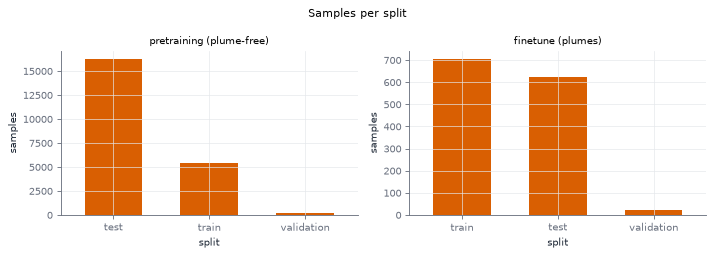

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
for a, ds, title in [(ax[0], pre_df, "pretraining (plume-free)"), (ax[1], ft_df, "finetune (plumes)")]:
    ds["split"].value_counts().plot.bar(ax=a, color=C.PALETTE["l89"], width=0.6)
    a.set_title(title, fontsize=9); a.set_ylabel("samples"); a.tick_params(axis="x", rotation=0)
fig.suptitle("Samples per split", fontsize=10); fig.tight_layout(); plt.show()

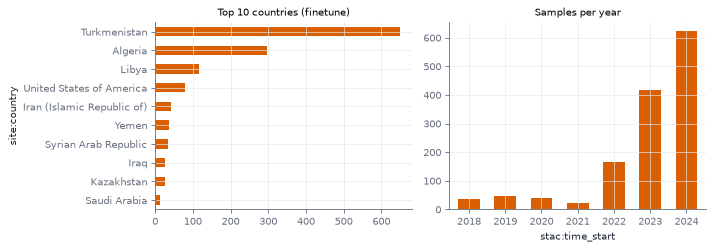

In [5]:
f = ft_df
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
f["site:country"].value_counts().head(10).iloc[::-1].plot.barh(ax=ax[0], color=C.PALETTE["l89"])
ax[0].set_title("Top 10 countries (finetune)", fontsize=9)
pd.to_datetime(f["stac:time_start"]).dt.year.value_counts().sort_index().plot.bar(
    ax=ax[1], color=C.PALETTE["l89"], width=0.6)
ax[1].set_title("Samples per year", fontsize=9); ax[1].tick_params(axis="x", rotation=0)
fig.tight_layout(); plt.show()

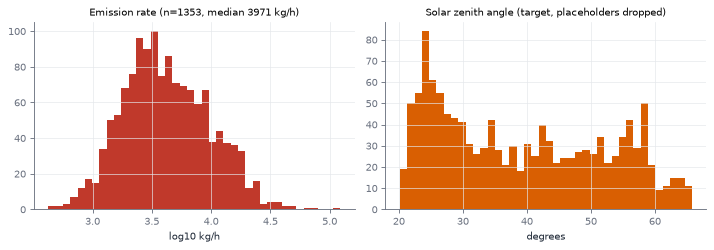

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
fl = pd.to_numeric(f["detection:ch4_fluxrate"], errors="coerce").dropna()
ax[0].hist(np.log10(fl), bins=40, color=C.PALETTE["ch4"])
ax[0].set_title(f"Emission rate (n={len(fl)}, median {fl.median():.0f} kg/h)", fontsize=9)
ax[0].set_xlabel("log10 kg/h")
sza = pd.to_numeric(f["target:sza"], errors="coerce")
ax[1].hist(sza[sza > 1].dropna(), bins=40, color=C.PALETTE["l89"])
ax[1].set_title("Solar zenith angle (target, placeholders dropped)", fontsize=9); ax[1].set_xlabel("degrees")
fig.tight_layout(); plt.show()

## 4. Anatomy of a sample
Each sample folder holds eight rasters: `target`, `bg0`..`bg3`, `ch4`, `plume`, `dem`.
`ch4` is the MARS retrieval in **ppb** (float64 on disk, read here as float32; nodata 0.0 and
`C.read` maps every exact zero to NaN, so negatives are the noise floor). It was computed using
the plume mask as an input, so treat it as a reference product, not an independent feature.
`plume` is a uint8 mask {0,1}.

In [7]:
f = ft_df
idx = f.sort_values("detection:ch4_fluxrate", ascending=False).query("`target:cloud` < 0.05").index[0]
s = ft.read(int(idx)); row = f.loc[idx]
print("flux (kg/h):", row["detection:ch4_fluxrate"], "| country:", row["site:country"], "| sza:", row["target:sza"])
tgt = C.read(s, "target"); bg0 = C.read(s, "bg0"); ch4 = C.read(s, "ch4", bands=1)
plume = C.read(s, "plume", bands=1)
print("target:", tgt.shape, tgt.dtype, "| ch4:", ch4.shape, ch4.dtype, "| plume:", np.unique(plume))

flux (kg/h): 122742.91 | country: United States of America | sza: 53.47
target: (11, 200, 200) float32 | ch4: (200, 200) float32 | plume: [0 1]


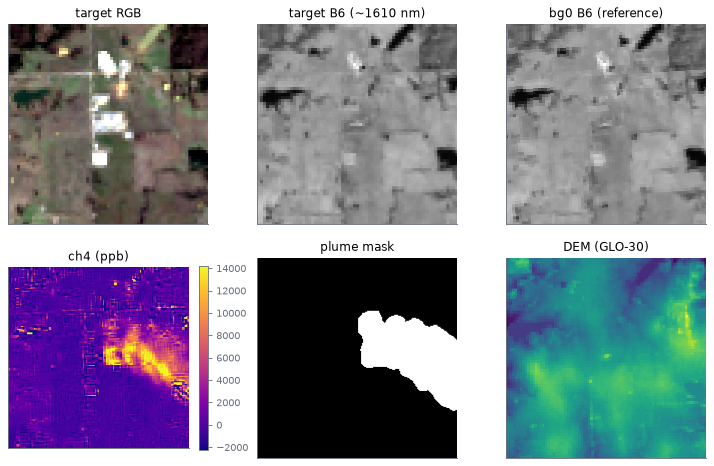

In [8]:
fig, ax = plt.subplots(2, 3, figsize=(9, 6))
ax[0,0].imshow(C.to_rgb(tgt, C.SENSORS["l89"]["rgb"])); ax[0,0].set_title("target RGB")
ax[0,1].imshow(tgt[5], cmap="gray"); ax[0,1].set_title("target B6 (~1610 nm)")
ax[0,2].imshow(bg0[5], cmap="gray"); ax[0,2].set_title("bg0 B6 (reference)")
im = ax[1,0].imshow(ch4, cmap=C.CMAP_ENH, vmax=np.nanpercentile(ch4, 99)); ax[1,0].set_title("ch4 (ppb)")
fig.colorbar(im, ax=ax[1,0], fraction=0.046)
ax[1,1].imshow(plume, cmap="gray"); ax[1,1].set_title("plume mask")
ax[1,2].imshow(C.read(s, "dem", bands=1)); ax[1,2].set_title("DEM (GLO-30)")
for a in ax.ravel(): a.set_xticks([]); a.set_yticks([])
fig.tight_layout(); plt.show()

## 5. MBMP, reproduced by hand
The multi-band multi-pass ratio compares the target with a plume-free reference over the
two SWIR bands (Varon et al. 2021): `d = (B7_t/B7_ref) / (B6_t/B6_ref) - 1`.
It is negative over the plume (extra absorption in B7).

std outside plume -> single bg: 0.1768 | median of 4 bgs: 0.2026
corr(MBMP bg0, ch4) inside the plume: -0.82


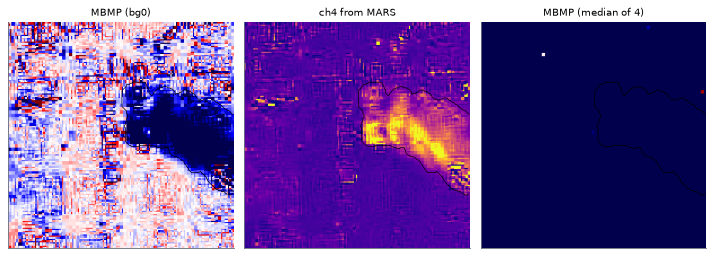

In [9]:
sw = C.SENSORS["l89"]["swir"]
d0 = C.mbmp(tgt[sw[0]], tgt[sw[1]], bg0[sw[0]], bg0[sw[1]])
mbs = [C.mbmp(tgt[sw[0]], tgt[sw[1]], *C.read(s, f"bg{k}", bands=sw)) for k in range(4)]
d_med = np.nanmedian(mbs, axis=0)
m = plume > 0
print("std outside plume -> single bg: %.4f | median of 4 bgs: %.4f" % (
    np.nanstd(d0[~m]), np.nanstd(d_med[~m])))
good = m & np.isfinite(d0) & np.isfinite(ch4)
print("corr(MBMP bg0, ch4) inside the plume: %.2f" % np.corrcoef(d0[good], ch4[good])[0, 1])
fig, ax = plt.subplots(1, 3, figsize=(9, 3.2))
for a, im, t in [(ax[0], d0, "MBMP (bg0)"), (ax[1], ch4, "ch4 from MARS"), (ax[2], d_med, "MBMP (median of 4)")]:
    im = a.imshow(im, cmap="seismic", vmin=-0.1, vmax=0.1) if "MBMP" in t else a.imshow(im, cmap=C.CMAP_ENH, vmax=np.nanpercentile(im, 99))
    a.contour(m, levels=[0.5], colors="k", linewidths=0.6); a.set_title(t, fontsize=9); a.set_xticks([]); a.set_yticks([])
fig.tight_layout(); plt.show()

## 6. A minimal pixel classifier (honest baseline)
Features per pixel: MBMP with bg0, MBMP median, B6/B7 of the target, normalised B7.
We train on 20 scenes of `split == train` and test on 8 of `test` (the split is grouped by
emitter, so there is no leakage). This is a baseline, not a state-of-the-art model.

In [10]:
f = ft_df
def features(s):
    sw = C.SENSORS["l89"]["swir"]
    t = C.read(s, "target"); b0 = C.read(s, "bg0", bands=sw)
    d0 = C.mbmp(t[sw[0]], t[sw[1]], b0[0], b0[1])
    dm = np.nanmedian([C.mbmp(t[sw[0]], t[sw[1]], *C.read(s, f"bg{k}", bands=sw)) for k in range(4)], axis=0)
    ratio = np.where(t[sw[1]] > 0, t[sw[0]] / (t[sw[1]] + 1e-9), 0)
    X = np.dstack([d0, dm, ratio, C.stretch(t[sw[1]])]).reshape(-1, 4)
    y = (np.asarray(C.read(s, "plume", bands=1)) > 0).reshape(-1)
    return np.nan_to_num(X), y

tr = f[f["split"] == "train"].sample(20, random_state=0).index
te = f[f["split"] == "test"].sample(8, random_state=0).index
Xtr, ytr = zip(*[features(ft.read(int(i))) for i in tr])
Xtr, ytr = np.vstack(Xtr), np.concatenate(ytr)
rng = np.random.default_rng(0)
pos = np.flatnonzero(ytr); neg = np.flatnonzero(~ytr)
sel = np.concatenate([pos, rng.choice(neg, min(len(neg), 50_000), replace=False)])
Xtr, ytr = Xtr[sel], ytr[sel]
print("train:", Xtr.shape, "| positives:", int(ytr.sum()))

train: (89602, 4) | positives: 39602


In [11]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(class_weight="balanced", max_iter=1000).fit(Xtr, ytr)
rows, preds = [], []
for i in te:
    s = ft.read(int(i)); X, y = features(s)
    H, W = C.read(s, "target").shape[1:]
    p = clf.predict(np.nan_to_num(X)); preds.append((s, p.reshape(H, W), y.reshape(H, W)))
    rows.append({"index": int(i), **{k: round(v, 3) for k, v in C.seg_metrics(p, y).items() if k in ("iou", "f1", "precision", "recall")}})
print(pd.DataFrame(rows).to_string(index=False))
print("mean IoU: %.3f | mean F1: %.3f" % (np.mean([r["iou"] for r in rows]), np.mean([r["f1"] for r in rows])))

 index   iou    f1  precision  recall
   762 0.032 0.062      0.034   0.318
   631 0.008 0.017      0.009   0.361
   924 0.201 0.335      0.217   0.737
   678 0.043 0.082      0.052   0.189
   928 0.074 0.138      0.078   0.609
   131 0.010 0.020      0.011   0.110
   527 0.014 0.028      0.041   0.021
   974 0.033 0.065      0.034   0.599
mean IoU: 0.052 | mean F1: 0.093


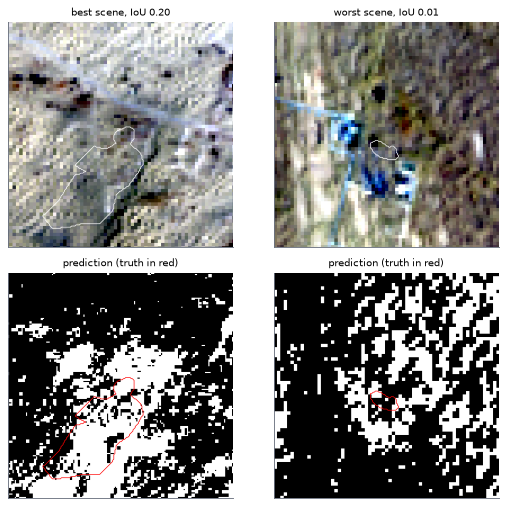

In [12]:
order = np.argsort([r["iou"] for r in rows])
fig, ax = plt.subplots(2, 2, figsize=(7, 6.4))
for col, (k, tag) in enumerate(zip([order[-1], order[0]], ["best", "worst"])):
    s, p, y = preds[k]
    ax[0, col].imshow(C.to_rgb(C.read(s, "target"), C.SENSORS["l89"]["rgb"]))
    ax[0, col].contour(y, levels=[0.5], colors="w", linewidths=0.6)
    ax[0, col].set_title(f"{tag} scene, IoU {rows[k]['iou']:.2f}", fontsize=9)
    ax[1, col].imshow(p, cmap="gray")
    ax[1, col].contour(y, levels=[0.5], colors="r", linewidths=0.6)
    ax[1, col].set_title("prediction (truth in red)", fontsize=9)
for a in ax.ravel(): a.set_xticks([]); a.set_yticks([])
fig.tight_layout(); plt.show()

## 7. The pretraining set: clean temporal pairs
Pretraining samples carry `target` and a plume-free `reference` (plus the DEM). They are the
negative pool and the backgrounds for synthetic injection.

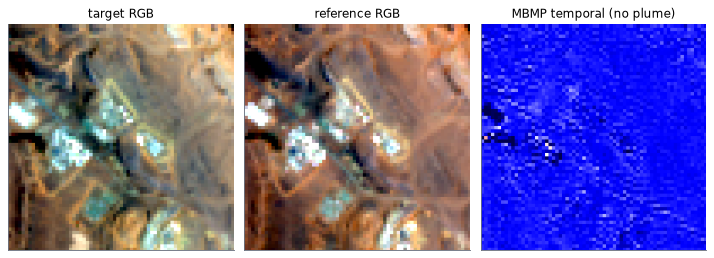

MBMP noise floor (std): 0.0104


In [13]:
s = pre.read(int(pre_df.index[0]))
t = C.read(s, "target"); r = C.read(s, "reference")
sw = C.SENSORS["l89"]["swir"]
d = C.mbmp(t[sw[0]], t[sw[1]], r[sw[0]], r[sw[1]])
fig, ax = plt.subplots(1, 3, figsize=(9, 3.2))
ax[0].imshow(C.to_rgb(t, C.SENSORS["l89"]["rgb"])); ax[0].set_title("target RGB")
ax[1].imshow(C.to_rgb(r, C.SENSORS["l89"]["rgb"])); ax[1].set_title("reference RGB")
ax[2].imshow(d, cmap="seismic", vmin=-0.1, vmax=0.1); ax[2].set_title("MBMP temporal (no plume)")
for a in ax: a.set_xticks([]); a.set_yticks([])
fig.tight_layout(); plt.show()
print("MBMP noise floor (std): %.4f" % np.nanstd(d))

## 8. Wrap-up
- The catalog (`level0`) answers most questions without touching a raster.
- `ch4` is the MARS retrieval (ppb, signed); `plume` is the binary mask; `bg0`..`bg3` are the four
  reference backgrounds (`bg0` is the one MARS used to compute `ch4`).
- The MBMP recomputed from the SWIR bands is anticorrelated with the distributed `ch4` inside the
  plume (r = -0.82, the sign the formula predicts). On this Landsat scene the median over the four backgrounds does not
  lower the residual noise (see the two std values above): the references are not always better
  registered than `bg0`.
- The classifier above is a deliberately small baseline; the paper benchmarks stronger models.

Next: `01_s2` (same tour for Sentinel-2), `03_emit` (hyperspectral), `04_bank` (synthetic plumes).
Website: https://ipl-uv.github.io/taco-methaneset · Dataset: https://huggingface.co/datasets/tacofoundation/methaneset

```bibtex
@article{contreras2026methaneset,
  title   = {MethaneSET: Unified Multi-Sensor AI-Ready Datasets for
             Satellite-Based Methane Plume Detection},
  author  = {Contreras, Julio and Giner, Carlos and Aybar, Cesar
             and Mateo-Garcia, Gonzalo and Gorrono, Javier
             and Montero, David and Mahecha, Miguel D.
             and Guanter, Luis and Gomez-Chova, Luis},
  journal = {Scientific Data},
  year    = {2026}
}
```